In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

#Exibe os gráficos dentro do notebook
%matplotlib inline


In [4]:
df = pd.read_csv('../data/train.csv')   
df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [5]:
df.shape

(891, 12)

In [6]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    str    
 4   Sex          891 non-null    str    
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    str    
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    str    
 11  Embarked     889 non-null    str    
dtypes: float64(2), int64(5), str(5)
memory usage: 83.7 KB


In [7]:
df.describe()

,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
count,891.000000,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,446.000000,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,257.353842,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,1.000000,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,223.500000,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,446.000000,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,668.500000,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,891.000000,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


In [8]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    str    
 4   Sex          891 non-null    str    
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    str    
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    str    
 11  Embarked     889 non-null    str    
dtypes: float64(2), int64(5), str(5)
memory usage: 83.7 KB


In [10]:
df.isnull().sum()

PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64

In [12]:
ausentes = pd.DataFrame({ 
"Valores Ausentes": df.isnull().sum(),
"Percentual (%)": (df.isnull().sum() / len(df) * 100).round(2)
})

ausentes.sort_values(by="Percentual (%)", ascending=False) 

,Valores Ausentes,Percentual (%)
Cabin,687,77.10
Age,177,19.87
Embarked,2,0.22
PassengerId,0,0.00
Name,0,0.00
Pclass,0,0.00
Survived,0,0.00
Sex,0,0.00
Parch,0,0.00
SibSp,0,0.00


In [19]:
df["Age"].describe()


count    714.000000
mean      29.699118
std       14.526497
min        0.420000
25%       20.125000
50%       28.000000
75%       38.000000
max       80.000000
Name: Age, dtype: float64

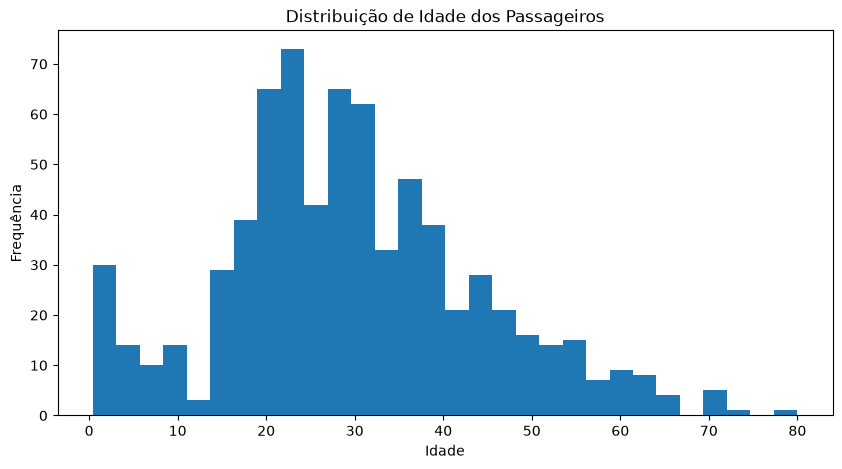

In [20]:
plt.figure(figsize=(10,5))
plt.hist(df["Age"].dropna(), bins=30)

plt.title("Distribuição de Idade dos Passageiros")
plt.xlabel("Idade")
plt.ylabel("Frequência")
plt.show()

C:\Users\Juliana\AppData\Local\Temp\ipykernel_7524\3873087502.py:3: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  plt.boxplot(df["Age"].dropna(),vert=False)


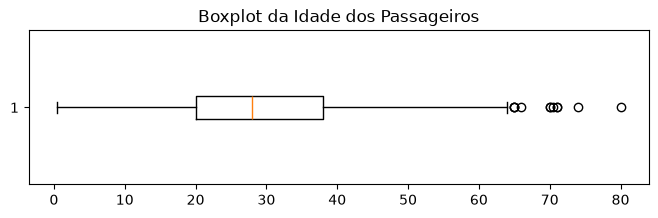

In [22]:
plt.figure(figsize=(8,2))

plt.boxplot(df["Age"].dropna(),vert=False)

plt.title("Boxplot da Idade dos Passageiros")

plt.show()

In [24]:
df["Survived"].value_counts()

Survived
0    549
1    342
Name: count, dtype: int64

In [31]:
df["Survived"].value_counts(normalize=True) * 100


Survived
0    61.616162
1    38.383838
Name: proportion, dtype: float64

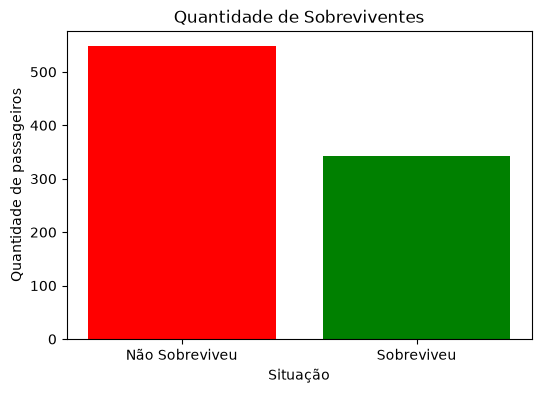

In [32]:
sobreviventes = df["Survived"].value_counts()

plt.figure(figsize=(6,4))

plt.bar(["Não Sobreviveu", "Sobreviveu"], sobreviventes, color=["red", "green"])
plt.title("Quantidade de Sobreviventes")
plt.xlabel("Situação")
plt.ylabel("Quantidade de passageiros")

plt.show()

In [36]:
pd.crosstab(df["Sex"], df["Survived"], normalize="index") * 100

Survived,0,1
Sex,,
female,25.796178,74.203822
male,81.109185,18.890815


In [ ]:
#Ao analisar a taxa de sobrevivência por sexo, observou-se que aproximadamente 74,2% das mulheres sobreviveram, enquanto apenas 18,9% dos homens sobreviveram. Esses resultados indicam uma diferença significativa entre os grupos. No entanto, essa análise isolada não permite concluir a causa da diferença, sendo necessária a investigação de outras variáveis, como classe social, idade e localização dos passageiros no navio.